# Goal: Inspect the period- eccentricity distribution 
Can we find any correlations:
- in (total) mass?
- per evolutionary type? 
- in total? 

(LvS: 06-02-26)

In [2]:
import json
import numpy as np
import pandas as pd
import sys, os

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize

from scipy.stats import gaussian_kde
from scipy.optimize import curve_fit

from pathlib import Path

# Ensure project root is on sys.path so `import paths` finds the top-level paths.py
proj_root = Path('/Users/liekevanson/Documents/Projects/post_mt_review').resolve()
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

from paths import DUMMY_CATALOG, MAIN_CATALOG, PLOTS_DIR, DOCS_DIR, LATEX_PLOT_DIR

file_path = MAIN_CATALOG


# Use mathtext (LaTeX-like without needing LaTeX)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif', 'Computer Modern Roman']
plt.rcParams['mathtext.fontset'] = 'cm'  # Computer Modern math font
plt.rcParams['font.size'] = 12


### Read json catalog into pandas table

In [3]:
# === Load JSON ===
def read_json_file(file_path):
    try:
        with open(file_path, "r") as f:
            data = json.load(f)
        return data
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

def extract_triplet_array(data, key):
    """Return an (N,3) float array for the given triplet key, robust to None/NaN."""
    rows = []
    for entry in data:
        val = entry.get(key, None)
        if isinstance(val, (list, tuple, np.ndarray)) and len(val) == 3:
            try:
                # Convert None to np.nan before float conversion
                rows.append([
                    np.nan if val[0] is None else float(val[0]),
                    np.nan if val[1] is None else float(val[1]),
                    np.nan if val[2] is None else float(val[2])
                ])
            except (TypeError, ValueError):
                rows.append([np.nan, np.nan, np.nan])
        elif isinstance(val, (int, float)):
            # Scalar provided, treat as central value with unknown errors
            rows.append([np.nan, float(val), np.nan])
        else:
            rows.append([np.nan, np.nan, np.nan])
    return np.array(rows, dtype=float)

In [4]:
# Read data
data = read_json_file(str(MAIN_CATALOG))
if data is None:
    print("No data loaded. Exiting.")
    exit(1)


In [5]:
# Extract triplet columns once for efficiency/consistency
RA_arr = extract_triplet_array(data, 'RA')
Dec_arr = extract_triplet_array(data, 'Dec')
period_arr = extract_triplet_array(data, 'Period')
ecc_arr = extract_triplet_array(data, 'Eccentricity')
m1_arr = extract_triplet_array(data, 'M1')
m2_arr = extract_triplet_array(data, 'M2')

# Build a single DataFrame with central values and errors
catalog_df = pd.DataFrame({
    'System Name': [entry.get('System Name', '') for entry in data],
    'RA': RA_arr[:, 1],
    'Dec': Dec_arr[:, 1],
    'Period': period_arr[:, 1],
    'Period_err_minus': period_arr[:, 0],
    'Period_err_plus': period_arr[:, 2],
    'Eccentricity': ecc_arr[:, 1],
    'Eccentricity_err_minus': ecc_arr[:, 0],
    'Eccentricity_err_plus': ecc_arr[:, 2],
    'M1': m1_arr[:, 1],
    'M1_err_minus': m1_arr[:, 0],
    'M1_err_plus': m1_arr[:, 2],
    'M2': m2_arr[:, 1],
    'M2_err_minus': m2_arr[:, 0],
    'M2_err_plus': m2_arr[:, 2],
    'obs_type_1': [entry.get('obs_type_1', '') for entry in data],
    'obs_type_2': [entry.get('obs_type_2', '') for entry in data],
    'evol_type_1': [entry.get('evol_type_1', '') for entry in data],
    'evol_type_2': [entry.get('evol_type_2', '') for entry in data],
    'system_class': [entry.get('system_class', 'None') for entry in data],
    'Simbad': [entry.get('Simbad', None) for entry in data]
})

In [6]:
display(catalog_df)

,System Name,RA,Dec,Period,Period_err_minus,Period_err_plus,Eccentricity,Eccentricity_err_minus,Eccentricity_err_plus,M1,...,M1_err_plus,M2,M2_err_minus,M2_err_plus,obs_type_1,obs_type_2,evol_type_1,evol_type_2,system_class,Simbad
0,Cl* NGC 188 PKM 451,8.700020,85.540940,722.000000,4.000000e+00,4.000000e+00,0.34,0.03,0.03,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
1,Cl* NGC 188 PKM 1888,13.631330,85.535900,2240.000000,3.000000e+01,3.000000e+01,0.21,0.04,0.04,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
2,Cl* NGC 188 PKM 2679,6.685930,85.310000,1033.000000,8.000000e+00,8.000000e+00,0.07,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
3,Cl* NGC 188 PKM 4348,10.923210,85.221480,1168.000000,8.000000e+00,8.000000e+00,0.09,0.05,0.05,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4,Cl* NGC 188 PKM 4540,11.326540,85.322200,3030.000000,7.000000e+01,7.000000e+01,0.36,0.07,0.07,NaN,...,NaN,NaN,NaN,NaN,None,None,MS,WD,Blue straggler binary,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4748,UCAC4 495-142916,297.473341,8.904363,0.748668,1.600000e-06,1.600000e-06,NaN,NaN,NaN,1.69,...,0.07,0.31,0.07,0.07,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4749,CRTS J225539.4+342138,118.713529,34.360512,0.571785,3.000000e-07,3.000000e-07,NaN,NaN,NaN,1.40,...,0.04,0.26,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4750,UCAC4 646-116578,123.282814,39.139678,0.766129,3.800000e-06,3.800000e-06,NaN,NaN,NaN,1.60,...,0.08,0.16,0.05,0.05,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...
4751,ZTF J225755.64+310133.7,127.228463,31.026046,0.688416,4.000000e-07,4.000000e-07,NaN,NaN,NaN,1.65,...,0.06,0.29,0.04,0.04,None,pre-He WD,MS,WD,EL CVn,https://simbad.cds.unistra.fr/simbad/sim-coo?C...


In [7]:
# System-class colours and symbols — imported from the shared module.
# Edit code/data_analysis/Category_dict.py to change colours/symbols everywhere.
import importlib
import Category_dict as category_dict

importlib.reload(category_dict)  # Pick up latest edits without restarting the kernel

SYSTEM_CLASS_MAP = category_dict.SYSTEM_CLASS_MAP
STYLE_MAP = category_dict.STYLE_MAP
COLORMAP = category_dict.COLORMAP
SYMBOLMAP = category_dict.SYMBOLMAP


In [8]:
# Helper function to increase darkness of a color
def darken_color(color, factor=0.7):
    """
    Darken a color by multiplying its RGB values by a factor.
    
    Parameters:
    -----------
    color : str or tuple
        Color as hex string (e.g., '#FF0000') or RGB tuple
    factor : float
        Factor to darken by (0-1). Lower = darker. Default 0.7
        
    Returns:
    --------
    str : Darkened color as hex string
    """
    import matplotlib.colors as mcolors
    
    # Convert to RGB if it's a hex string
    rgb = mcolors.to_rgb(color)
    
    # Multiply each channel by the factor
    darkened_rgb = tuple(c * factor for c in rgb)
    
    # Convert back to hex
    return mcolors.to_hex(darkened_rgb)

# Example usage:
# darker_green = darken_color(mass_colors[0], factor=0.6)
# ax.plot(x, y, color=darker_green)

# General P-e diagram

/Users/liekevanson/Documents/Projects/post_mt_review/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


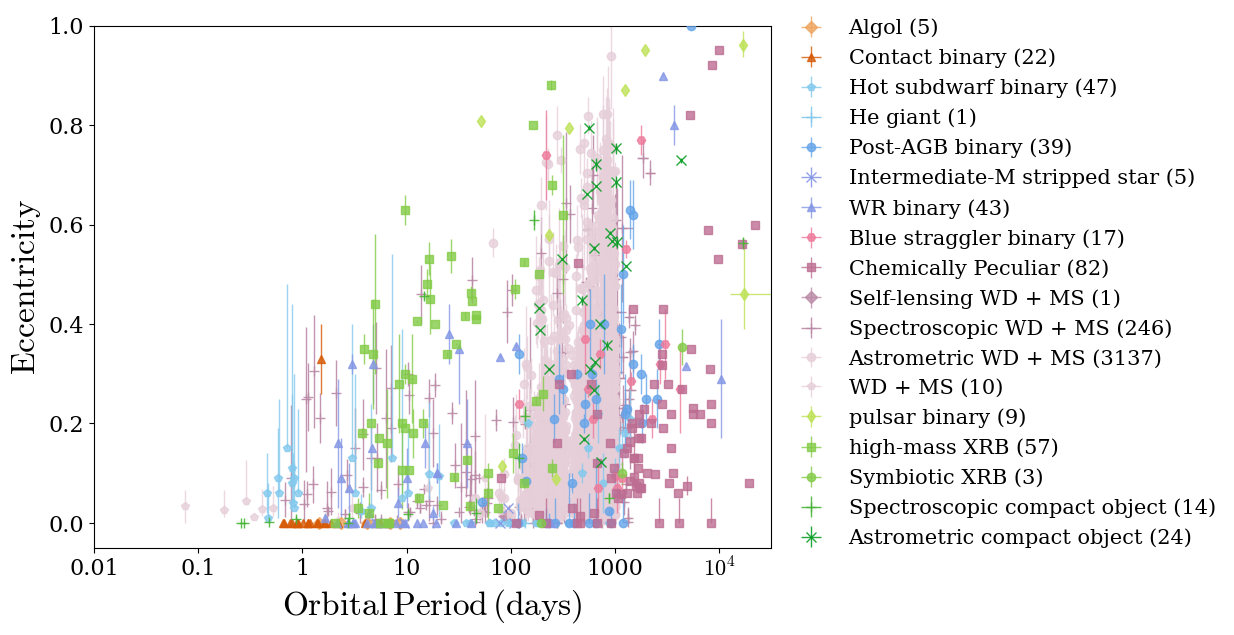

In [9]:
fig, ax = plt.subplots(figsize=(12.5, 6.5))

plot_df = catalog_df.copy()

# Keep only rows with valid central values; log-x also requires Period > 0.
plot_df = plot_df.dropna(subset=['Period', 'Eccentricity']).copy()
plot_df = plot_df[plot_df['Period'] > 0].copy()

# Propagate Period errors into log10 space: d(log P) = dP / (P ln 10)
plot_df['period_err_minus_log'] = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
plot_df['period_err_plus_log'] = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Keep eccentricity errors physical: e - err >= 0 and e + err <= 1
mask_min = plot_df['Eccentricity'] - plot_df['Eccentricity_err_minus'] < 0
plot_df.loc[mask_min, 'Eccentricity_err_minus'] = plot_df.loc[mask_min, 'Eccentricity']
mask_plus = plot_df['Eccentricity'] + plot_df['Eccentricity_err_plus'] > 1
plot_df.loc[mask_plus, 'Eccentricity_err_plus'] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Missing uncertainties are treated as zero-length error bars
plot_df['period_err_minus_log'] = plot_df['period_err_minus_log'].fillna(0)
plot_df['period_err_plus_log'] = plot_df['period_err_plus_log'].fillna(0)
plot_df['Eccentricity_err_minus'] = plot_df['Eccentricity_err_minus'].fillna(0)
plot_df['Eccentricity_err_plus'] = plot_df['Eccentricity_err_plus'].fillna(0)

# Keep error bars physical: no negative period, and eccentricity bounded [0,1].
mask_pmin = plot_df['Period'] - plot_df['Period_err_minus'] < 0
plot_df.loc[mask_pmin, 'Period_err_minus'] = plot_df.loc[mask_pmin, 'Period']

mask_emin = plot_df['Eccentricity'] - plot_df['Eccentricity_err_minus'] < 0
plot_df.loc[mask_emin, 'Eccentricity_err_minus'] = plot_df.loc[mask_emin, 'Eccentricity']

mask_eplus = plot_df['Eccentricity'] + plot_df['Eccentricity_err_plus'] > 1
plot_df.loc[mask_eplus, 'Eccentricity_err_plus'] = 1 - plot_df.loc[mask_eplus, 'Eccentricity']

# Plotly-style symbols mapped to matplotlib markers.
plotly_to_mpl_marker = {
    'circle': 'o',
    'circle-open': 'o',
    'square': 's',
    'square-open': 's',
    'diamond': 'D',
    'diamond-open': 'D',
    'diamond-tall': 'd',
    'cross': '+',
    'cross-dot': '+',
    'plus': '+',
    '+': '+',
    'x': 'x',
    'triangle-up': '^',
    'triangle-up-open': '^',
    'star': '*',
    'pentagon': 'p',
    'pentagon-open': 'p',
    'hourglass': 'H',
    'square-x': '+',
    'cross-thin-open': 'x',
}


# Plot each system class separately so style/legend are per class.
for system_class in STYLE_MAP.keys():
    sub = plot_df[plot_df['system_class'] == system_class]
    if sub.empty:
        continue
    # Move the WDs to the back
    Zord = 3 if 'WD' not in system_class else 0

    color = COLORMAP.get(system_class, '#666666')
    marker_plotly = SYMBOLMAP.get(system_class, 'circle')
    marker_mpl = plotly_to_mpl_marker.get(marker_plotly, 'o')

    ax.errorbar(np.log10(sub['Period']),sub['Eccentricity'],
        xerr=[sub['period_err_minus_log'], sub['period_err_plus_log']],
        yerr=[sub['Eccentricity_err_minus'], sub['Eccentricity_err_plus']],
        fmt=marker_mpl, ms=7 if marker_mpl in ['+', 'x'] else 6,
        color=color, ecolor=color,
        elinewidth=1, capsize=0,
        alpha=0.9 if marker_mpl in ['+', 'x'] else 0.8,
        linestyle='none', zorder=Zord,
        label=f"{system_class} ({len(sub)})"
    )


# Write x ticks not in log space but in days
xticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
xtick_labels = ['0.01', '0.1', '1', '10', '100', '1000', '$10^4$']
plt.xticks(np.log10(xticks), xtick_labels, fontsize=20) 


ax.set_xlim(-2, 4.5)
ax.set_ylim(-0.05, 1)
ax.tick_params(axis='both', labelsize=16)
ax.set_xlabel('$\mathrm{Orbital\,Period\,(days)}$', fontsize=24)
ax.set_ylabel('$\mathrm{Eccentricity}$', fontsize=24)
ax.legend(bbox_to_anchor=(1, 1.05), loc='upper left', fontsize=15, framealpha=0., ncol=1)
plt.tight_layout()
plt.savefig(LATEX_PLOT_DIR / 'P_e_by_system_class.pdf')
plt.savefig(PLOTS_DIR / 'P_e_by_system_class.pdf')
plt.show()


# Plot the P-e distribution colored by mass

Low-mass categories: ['WD binary', 'Low-M stripped']
Low-mass classes: ['Astrometric WD + MS', 'Blue straggler binary', 'Chemically Peculiar', 'EL CVn', 'He giant', 'Hot subdwarf binary', 'Post-AGB binary', 'Self-lensing WD + MS', 'Spectroscopic WD + MS', 'WD + MS']
High-mass categories: ['Ongoing RLOF', 'High-M stripped', 'CO binary']
High-mass classes: ['Algol', 'Astrometric compact object', 'Contact binary', 'Intermediate-M stripped star', 'Spectroscopic compact object', 'Symbiotic XRB', 'WR binary', 'high-mass XRB', 'pulsar binary']
  Mtot range: 0.34 - 18.63
  Mtot range: 1.32 - 92.20
Low-mass systems N systems in each period bin P_bin
(-1.0, -0.167]        9
(-0.167, 0.667]      33
(0.667, 1.5]         35
(1.5, 2.333]        247
(2.333, 3.167]     3187
(3.167, 4.0]         64
NaN                   5
Name: count, dtype: int64 3580
High-mass systems N systems in each period bin P_bin
(-1.0, -0.167]      5
(-0.167, 0.667]    43
(0.667, 1.5]       57
(1.5, 2.333]       35
(2.333, 3.1

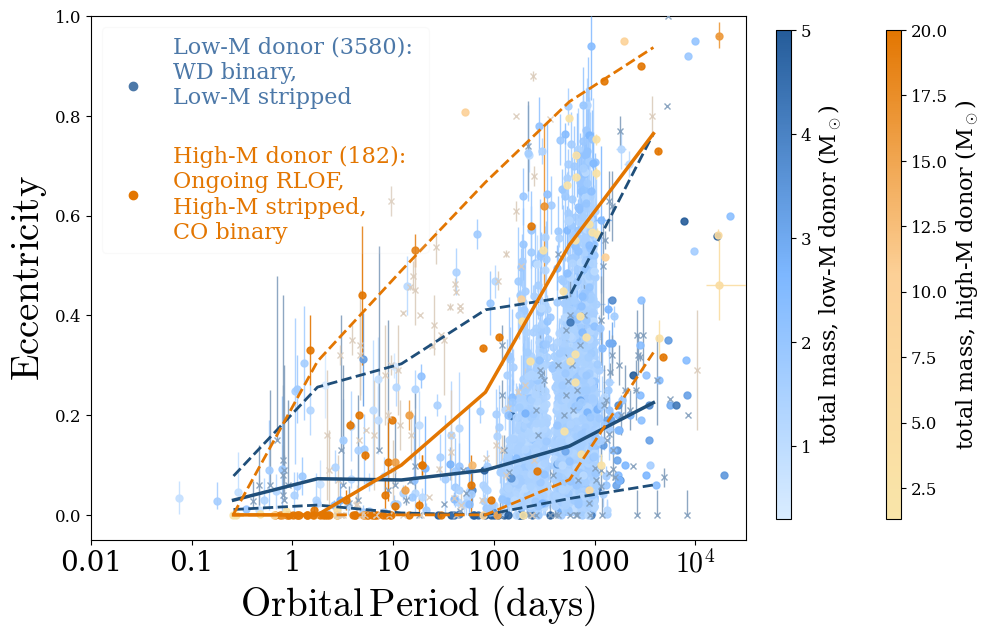

In [18]:
fig, ax = plt.subplots(figsize=(10, 6.8))

# ------------------------------------------------------------------
# 1) Prepare base dataframe and derived columns
# ------------------------------------------------------------------
plot_df = catalog_df.copy()
plot_df = plot_df[plot_df['Period'] > 0].copy()
plot_df['log_Period'] = np.log10(plot_df['Period'])
plot_df['Mtot'] = plot_df['M1'] + plot_df['M2']

# ------------------------------------------------------------------
# Prepare uncertainty columns used for error bars
# ------------------------------------------------------------------
# Propagate Period errors into log10 space: d(log P) = dP / (P ln 10)
plot_df['period_err_minus_log'] = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
plot_df['period_err_plus_log'] = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Keep eccentricity errors physical: e - err >= 0 and e + err <= 1
mask_min = plot_df['Eccentricity'] - plot_df['Eccentricity_err_minus'] < 0
plot_df.loc[mask_min, 'Eccentricity_err_minus'] = plot_df.loc[mask_min, 'Eccentricity']
mask_plus = plot_df['Eccentricity'] + plot_df['Eccentricity_err_plus'] > 1
plot_df.loc[mask_plus, 'Eccentricity_err_plus'] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Missing uncertainties are treated as zero-length error bars
plot_df['period_err_minus_log'] = plot_df['period_err_minus_log'].fillna(0)
plot_df['period_err_plus_log'] = plot_df['period_err_plus_log'].fillna(0)
plot_df['Eccentricity_err_minus'] = plot_df['Eccentricity_err_minus'].fillna(0)
plot_df['Eccentricity_err_plus'] = plot_df['Eccentricity_err_plus'].fillna(0)


# ------------------------------------------------------------------
# Define low/high mass bins from system categories
# ------------------------------------------------------------------
low_mass_categories = ['WD binary', 'Low-M stripped']
high_mass_categories = ['Ongoing RLOF', 'High-M stripped', 'CO binary']

low_mass_classes = set()
for cat in low_mass_categories:
    low_mass_classes |= set(SYSTEM_CLASS_MAP[cat].keys())

high_mass_classes = set()
for cat in high_mass_categories:
    high_mass_classes |= set(SYSTEM_CLASS_MAP[cat].keys())

# Print the exact category setup used in this plot
print('Low-mass categories:', low_mass_categories)
print('Low-mass classes:', sorted(low_mass_classes))
print('High-mass categories:', high_mass_categories)
print('High-mass classes:', sorted(high_mass_classes))

# Keep rows with valid plotting axes and assign each row to a mass bin
plot_df = plot_df.dropna(subset=['log_Period', 'Eccentricity']).copy()
plot_df['mass_bin'] = np.where(
    plot_df['system_class'].isin(low_mass_classes),
    'Low-mass systems',
    np.where(plot_df['system_class'].isin(high_mass_classes), 'High-mass systems', 'Unclassified')
)
plot_df = plot_df[plot_df['mass_bin'] != 'Unclassified'].copy()

# ------------------------------------------------------------------
#  Build separate colormaps for the two bins
# ------------------------------------------------------------------
# Blue gradient for low-mass systems; red gradient for high-mass systems
low_mass_cmap = mcolors.LinearSegmentedColormap.from_list(
    'low_mass_gradient', ['#d9ecff', '#7db7ff', '#255c99']
)
high_mass_cmap = mcolors.LinearSegmentedColormap.from_list(
    'high_mass_gradient', ['#f9e5a9', '#fcd097', '#e37601']
)

# Split by (mass bin) x (known / unknown total mass)
low_known = plot_df[(plot_df['mass_bin'] == 'Low-mass systems') & plot_df['Mtot'].notna()].copy()
low_unknown = plot_df[(plot_df['mass_bin'] == 'Low-mass systems') & plot_df['Mtot'].isna()].copy()
high_known = plot_df[(plot_df['mass_bin'] == 'High-mass systems') & plot_df['Mtot'].notna()].copy()
high_unknown = plot_df[(plot_df['mass_bin'] == 'High-mass systems') & plot_df['Mtot'].isna()].copy()

# Construct per-bin normalization for colorbars from available Mtot range
def build_norm(values):
    vmin = values.min()
    vmax = values.max()
    print(f"  Mtot range: {vmin:.2f} - {vmax:.2f}")
    if np.isclose(vmin, vmax):
        vmax = vmin + 1e-6
    return Normalize(vmin=vmin, vmax=vmax)

build_norm(low_known['Mtot']) if not low_known.empty else None
low_norm = Normalize(vmin=0.3, vmax=5) #

high_norm = Normalize(vmin=1.3, vmax=20) # 
build_norm(high_known['Mtot']) if not high_known.empty else None
# ------------------------------------------------------------------
# Plot points WITH errorbars, colored by total mass if known
# ------------------------------------------------------------------
# Known-mass points use gradients + colorbars; unknown-mass points use flat fallback colors
first_low_label = True
for _, row in low_known.iterrows():
    color = low_mass_cmap(low_norm(row['Mtot']))
    ax.errorbar(
        row['log_Period'], row['Eccentricity'],
        xerr=[[row['period_err_minus_log']], [row['period_err_plus_log']]],
        yerr=[[row['Eccentricity_err_minus']], [row['Eccentricity_err_plus']]],
        fmt='o', ms=5, color=color, ecolor=color, elinewidth=1, capsize=0,
        alpha=0.9, zorder=3,
        label='Low-mass systems' if first_low_label else None
    )
    first_low_label = False

for _, row in low_unknown.iterrows():
    ax.errorbar(
        row['log_Period'], row['Eccentricity'],
        xerr=[[row['period_err_minus_log']], [row['period_err_plus_log']]],
        yerr=[[row['Eccentricity_err_minus']], [row['Eccentricity_err_plus']]],
        fmt='x', ms=5, color='#829ebc', ecolor='#829ebc', elinewidth=1, capsize=0,
        alpha=0.9, zorder=3
    )

first_high_label = True
for _, row in high_known.iterrows():
    color = high_mass_cmap(high_norm(row['Mtot']))
    ax.errorbar(
        row['log_Period'], row['Eccentricity'],
        xerr=[[row['period_err_minus_log']], [row['period_err_plus_log']]],
        yerr=[[row['Eccentricity_err_minus']], [row['Eccentricity_err_plus']]],
        fmt='o', ms=5, color=color, ecolor=color, elinewidth=1, capsize=0,
        alpha=0.9, zorder=3,
        label='High-mass systems' if first_high_label else None
    )
    first_high_label = False

for _, row in high_unknown.iterrows():
    ax.errorbar(
        row['log_Period'], row['Eccentricity'],
        xerr=[[row['period_err_minus_log']], [row['period_err_plus_log']]],
        yerr=[[row['Eccentricity_err_minus']], [row['Eccentricity_err_plus']]],
        fmt='x', ms=5, color='#dbccbc', ecolor='#dbccbc', elinewidth=1, capsize=0,
        alpha=0.9, zorder=3
    )

# ------------------------------------------------------------------
# Median and spread per mass bin
# ------------------------------------------------------------------
# Plot median e(log P) and a 5-95 percentile envelope for each bin
median_styles = {
    'Low-mass systems': {'color': '#1f4e79', 'label': 'Low-mass median'},
    'High-mass systems': {'color': '#e37601', 'label': 'High-mass median'},
}
P_bins = np.linspace(-1, 4, 7)
x_stats = P_bins[:-1] + 0.5 * np.diff(P_bins)
N_in_class = []

for mass_bin, style in median_styles.items():
    subset = plot_df[plot_df['mass_bin'] == mass_bin].copy()
    subset['P_bin'] = pd.cut(subset['log_Period'], bins=P_bins)
    
    # To know how statistically robust each bin is:
    counts_by_bin = subset['P_bin'].value_counts(sort=False, dropna=False)
    N_in_class.append(sum(counts_by_bin))
    print(mass_bin,'N systems in each period bin', counts_by_bin, N_in_class[-1])

    #Get the median and 5-95 percentile for each P_bin, ignoring empty bins
    stats = subset.groupby('P_bin', observed=False)['Eccentricity'].quantile([0.05, 0.5, 0.95]).unstack()
    stats.columns = ['p05', 'median', 'p95']

    ax.plot(x_stats, stats['median'].values, lw=2.5, c=style['color'], label=style['label'], zorder=4)
    ax.plot(x_stats, stats['p05'].values, lw=2, ls='--', c=style['color'], label=None, zorder=4)
    ax.plot(x_stats, stats['p95'].values, lw=2, ls='--', c=style['color'], label=None, zorder=4)
    # ax.fill_between(x_stats, stats['p05'].values, stats['p95'].values, color=style['color'], alpha=0.12, step='mid', zorder=2)

# ------------------------------------------------------------------
# 8) Add one colorbar per mass bin (if masses are available)
# ------------------------------------------------------------------
# Reserve space on the right for custom colorbar axes
fig.subplots_adjust(right=0.78)

# [left, bottom, width, height] in figure fraction coordinates (0..1)
cax_low  = fig.add_axes([0.81, 0.14, 0.015, 0.72])
cax_high = fig.add_axes([0.92, 0.14, 0.015, 0.72])

if low_norm is not None:
    sm_low = plt.cm.ScalarMappable(cmap=low_mass_cmap, norm=low_norm)
    sm_low.set_array([])
    cbar_low = fig.colorbar(sm_low, cax=cax_low)
    # cbar_low.set_ticks([low_norm.vmin, low_norm.vmax])
    cbar_low.set_label('total mass, low-M donor (M$_\\odot$)', fontsize=16)

if high_norm is not None:
    sm_high = plt.cm.ScalarMappable(cmap=high_mass_cmap, norm=high_norm)
    sm_high.set_array([])
    cbar_high = fig.colorbar(sm_high, cax=cax_high)
    # cbar_high.set_ticks([high_norm.vmin, high_norm.vmax])
    cbar_high.set_label('total mass, high-M donor (M$_\\odot$)', fontsize=16) # labelpad=-1

# ------------------------------------------------------------------
# 9) Final formatting and export
# ------------------------------------------------------------------

# Write x ticks not in log space but in days
xticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
xtick_labels = ['0.01', '0.1', '1', '10', '100', '1000', '$10^4$']
ax.set_xticks(np.log10(xticks))
ax.set_xticklabels(xtick_labels, fontsize=20)


from matplotlib.lines import Line2D

legend_handles = [
    Line2D([0], [0], marker='o', linestyle='None', color='#4c78a8', markersize=6,
           label=f"Low-M donor ({N_in_class[0]}): \nWD binary, \nLow-M stripped\n"),
    Line2D([0], [0], marker='o', linestyle='None', color='#e37601', markersize=6,
           label=f"High-M donor ({N_in_class[1]}): \nOngoing RLOF, \nHigh-M stripped, \nCO binary"),
]
legend = ax.legend(handles=legend_handles, fontsize=16, loc = 'upper left', bbox_to_anchor=(0.0, 1), framealpha=0.1)
legend.get_texts()[0].set_color('#4c78a8')
legend.get_texts()[1].set_color('#e37601')
ax.set_xlim(-2, 4.5)
ax.set_ylim(-0.05, 1)
ax.tick_params(axis='x', labelsize=20)
ax.set_xlabel('$\mathrm{Orbital \, Period \ (days)}$', fontsize=28)
ax.set_ylabel('$\\mathrm{Eccentricity}$', fontsize=28)
plt.savefig(LATEX_PLOT_DIR / 'P_e_diagram_2massbins_median.pdf', bbox_inches='tight')
plt.savefig(PLOTS_DIR / 'P_e_diagram_2massbins_median.pdf', bbox_inches='tight')
plt.show()


/var/folders/5d/vcxrsh5975l7d5n8t7vvc5pr0000gn/T/ipykernel_49175/3565312856.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = plot_df.groupby('P_bin')['Eccentricity'].quantile([0.05, 0.5, 0.95]).unstack()


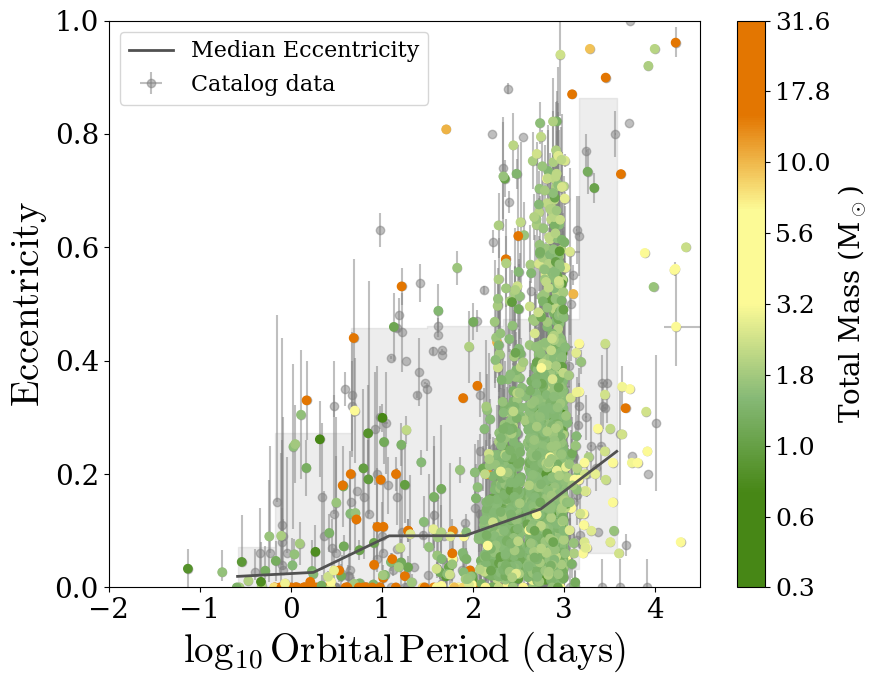

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))

plot_df = catalog_df.copy()

plot_df['log_Period'] = np.log10(plot_df['Period'])

###### Handling errors ######
# Propagate errors for logP: d(log P) = 1/ln(10) *  dP /P 
period_err_minus_log = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
period_err_plus_log = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Check that E errors don't drop below zero
# wherever the value minus the minus error is <0, set the minus error to the value itself
mask_min = plot_df['Eccentricity'] - plot_df["Eccentricity_err_minus"] < 0
plot_df.loc[mask_min, "Eccentricity_err_minus"] = plot_df.loc[mask_min, 'Eccentricity'] 
# Also ensure that Eccentricities do not exceed 1
mask_plus = plot_df['Eccentricity'] + plot_df["Eccentricity_err_plus"] > 1
plot_df.loc[mask_plus, "Eccentricity_err_plus"] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Fill NaN errors with zero
period_err_minus_log = period_err_minus_log.fillna(0)
period_err_plus_log = period_err_plus_log.fillna(0)
ecc_err_minus = plot_df['Eccentricity_err_minus'].fillna(0)
ecc_err_plus = plot_df['Eccentricity_err_plus'].fillna(0)


###### Actual plotting ######
## P vs e inlcuding errors ##
ax.errorbar(plot_df['log_Period'], (plot_df['Eccentricity']),
            xerr=[period_err_minus_log, period_err_plus_log], 
            yerr=[ecc_err_minus, ecc_err_plus], zorder = 0,
            fmt='o', c='gray', alpha=0.5, label = 'Catalog data')  

## Show Median and 1-sigma ##
P_bins = np.linspace(-1,4, 7)
plot_df['P_bin'] = pd.cut(plot_df['log_Period'], bins=P_bins)
stats = plot_df.groupby('P_bin')['Eccentricity'].quantile([0.05, 0.5, 0.95]).unstack()
stats.columns = ['p05', 'median', 'p95']

x_stats = P_bins[:-1] + 0.5 * np.diff(P_bins)
plt.plot(x_stats, stats['median'].values, lw=2, c = '#515151', label = 'Median Eccentricity')
plt.fill_between(x_stats, stats['p05'].values, stats['p95'].values, color='#515151', alpha=0.1, step='mid', zorder=-1)

## Now overplot colored by total mass ##
plot_df['Mtot'] = plot_df['M1'] + plot_df['M2']
plot_df['log_Mtot'] = np.log10(plot_df['Mtot'])
mass_color_key = 'log_Mtot'

#enforce not na for all three parameters of interest (log_Period, Eccentricity, Mtot)
plot_df = plot_df.dropna(subset=['log_Period', 'Eccentricity', mass_color_key])
mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#478716', '#478716', '#86b976', '#fcfa96', '#fcfa96','#e37601','#e37601'])

mass_sc = ax.scatter(plot_df['log_Period'], plot_df['Eccentricity'], 
                    c = plot_df[mass_color_key], cmap=mass_cmap,
                    vmin = -0.5, vmax=1.5)  # Set vmin and vmax for consistent color scaling
cbar = plt.colorbar(mass_sc, ax=ax)


# Set colorbar ticks to show original (non-log) values
tick_locs = cbar.get_ticks() # Get the current tick positions (in log space)
tick_labels = [f'{10**tick:.1f}' for tick in tick_locs] # Convert back from log10 to original values
cbar.set_ticks(tick_locs, labels=tick_labels)

cbar.set_label('Total Mass (M$_\odot$)', fontsize=20)
cbar.ax.tick_params(labelsize=18)


###### Plot values ######
plt.xlim(-2,4.5)
plt.ylim(0,1)
# ax.set_xscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\log_{10} \mathrm{Orbital\,Period \ (days)}$', fontsize=28)
plt.ylabel('$\mathrm{Eccentricity}$', fontsize=28)
plt.tight_layout()
ax.legend(fontsize=16)
plt.savefig(LATEX_PLOT_DIR / 'P_e_diagram_cmass_median.pdf')
plt.savefig(PLOTS_DIR / 'P_e_diagram_cmass_median.pdf')
plt.show()

In [12]:
# Alternative colormaps 
# # mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#afcfce', '#99b6a0', '#368979','#2a7595','#0d3d47'])
# mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#d3e29d', '#acc864', '#8ab446','#2d6b22','#072a16'])
# mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#6f9c3d', '#a5c90f', '#fcfa96','#ed6c10','#9c3842'])
# mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#6a9c43', '#86b976', '#8fbc93','#d3dbb4','#e37601'])

# P-e distribution per category

WD binary N systems in each period bin P_bin
(-1.0, -0.167]      251
(-0.167, 0.667]     128
(0.667, 1.5]         67
(1.5, 2.333]        237
(2.333, 3.167]     3150
(3.167, 4.0]         56
NaN                 159
Name: count, dtype: int64
Ongoing RLOF N systems in each period bin P_bin
(-1.0, -0.167]       4
(-0.167, 0.667]    109
(0.667, 1.5]        33
(1.5, 2.333]         2
(2.333, 3.167]       0
(3.167, 4.0]         0
Name: count, dtype: int64
Low-M stripped stars N systems in each period bin P_bin
(-1.0, -0.167]     72
(-0.167, 0.667]    81
(0.667, 1.5]       26
(1.5, 2.333]       33
(2.333, 3.167]     64
(3.167, 4.0]        8
NaN                 8
Name: count, dtype: int64
High-M stripped stars N systems in each period bin P_bin
(-1.0, -0.167]      0
(-0.167, 0.667]    14
(0.667, 1.5]       23
(1.5, 2.333]        8
(2.333, 3.167]      1
(3.167, 4.0]        3
NaN                 4
Name: count, dtype: int64
CO binary N systems in each period bin P_bin
(-1.0, -0.167]      4
(-0.167, 

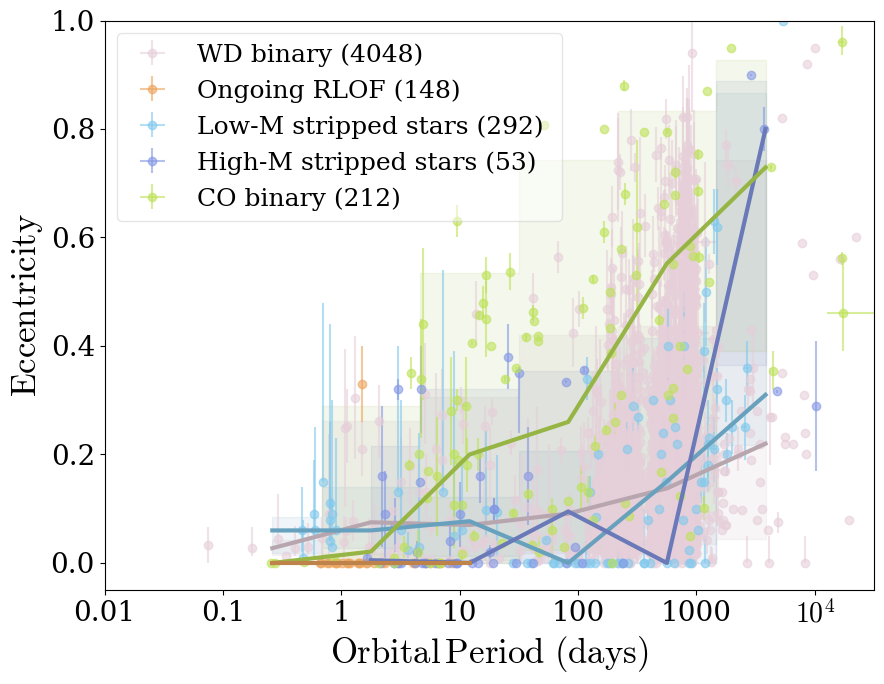

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))


plot_df = catalog_df.copy()

plot_df['log_Period'] = np.log10(plot_df['Period'])

###### Handling errors ######
# Propagate errors for logP: d(log P) = 1/ln(10) *  dP /P 
plot_df['period_err_minus_log'] = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
plot_df['period_err_plus_log'] = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Check that E errors don't drop below zero
# wherever the value minus the minus error is <0, set the minus error to the value itself
mask_min = plot_df['Eccentricity'] - plot_df["Eccentricity_err_minus"] < 0
plot_df.loc[mask_min, "Eccentricity_err_minus"] = plot_df.loc[mask_min, 'Eccentricity'] 
# Also ensure that Eccentricities do not exceed 1
mask_plus = plot_df['Eccentricity'] + plot_df["Eccentricity_err_plus"] > 1
plot_df.loc[mask_plus, "Eccentricity_err_plus"] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Fill NaN errors with zero
plot_df['period_err_minus_log'] = plot_df['period_err_minus_log'].fillna(0)
plot_df['period_err_plus_log'] = plot_df['period_err_plus_log'].fillna(0)
plot_df['Eccentricity_err_minus'] = plot_df['Eccentricity_err_minus'].fillna(0)
plot_df['Eccentricity_err_plus'] = plot_df['Eccentricity_err_plus'].fillna(0)

# Combine Low-M and High-M stripped into a single plotted category.
plot_category_map = {
    'WD binary': ['WD binary'],
    'Ongoing RLOF': ['Ongoing RLOF'],
    'Low-M stripped stars': ['Low-M stripped'],
    'High-M stripped stars': ['High-M stripped'],
    'CO binary': ['CO binary'],
}

for category, source_categories in plot_category_map.items():
    zorder = 1  

    # Combine all system classes from one or more source categories.
    system_classes_in_category = []
    for src_category in source_categories:
        system_classes_in_category.extend(list(SYSTEM_CLASS_MAP[src_category].keys()))

    if src_category == 'Ongoing RLOF':
        zorder += 1  # plot RLOF systems on top of the others

    subset = plot_df[plot_df['system_class'].isin(system_classes_in_category)].copy()
    log_periods = np.log10(subset['Period'].dropna())

    # Use one representative color per plotted category.
    first_source = source_categories[0]
    first_system_color = list(SYSTEM_CLASS_MAP[first_source].values())[0]['color']
    if category == 'WD binary':
        first_system_color = list(SYSTEM_CLASS_MAP['WD binary'].values())[-1]['color']  # override with last color

    ###### Actual plotting ######
    ax.errorbar(subset['log_Period'], (subset['Eccentricity']),
                xerr=[subset['period_err_minus_log'], subset['period_err_plus_log']], 
                yerr=[subset['Eccentricity_err_minus'].fillna(0), subset['Eccentricity_err_plus'].fillna(0)], 
                fmt='o', c=first_system_color, alpha=0.6,zorder = 1,
                label=f"{category} ({subset.shape[0]}) ")  

    ## Show Median and 1-sigma ##
    P_bins = np.linspace(-1,4, 7)
    subset['P_bin'] = pd.cut(subset['log_Period'], bins=P_bins)

    # To know how statistically robust each bin is:
    counts_by_bin = subset['P_bin'].value_counts(sort=False, dropna=False)
    print(category,'N systems in each period bin', counts_by_bin)
    
    # Get the median and 5-95 percentile for each P_bin, ignoring empty bins
    stats = subset.groupby('P_bin', observed=False)['Eccentricity'].quantile([0.05, 0.5, 0.95]).unstack()
    stats.columns = ['p05', 'median', 'p95']

    x_stats = P_bins[:-1] + 0.5 * np.diff(P_bins)
    ax.plot(x_stats, stats['median'].values, 
            lw=3, c = darken_color(first_system_color, factor=0.8), zorder = 2+ zorder)
    ax.fill_between(x_stats, stats['p05'].values, stats['p95'].values, 
                    color=darken_color(first_system_color, factor=0.8), alpha=0.1, step='mid', zorder=-1)


# Write x ticks not in log space but in days
xticks = [0.01, 0.1, 1, 10, 100, 1000, 10000]
xtick_labels = ['0.01', '0.1', '1', '10', '100', '1000', '$10^4$']
plt.xticks(np.log10(xticks), xtick_labels, fontsize=20) 


# Plot formatting
# Set tick labels to be larger and use mathtext for the x-axis
plt.xlim(-2,4.5)
plt.ylim(-0.05,1)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\mathrm{Orbital\,Period \ (days)}$', fontsize=25)
plt.ylabel('$\mathrm{Eccentricity}$', fontsize=25)
plt.legend(loc='upper left', fontsize=18, framealpha = 0.5)#bbox_to_anchor=(0.05, 0.95),
plt.tight_layout()
plt.savefig(LATEX_PLOT_DIR / 'P_e_by_category_median.pdf')
plt.savefig(PLOTS_DIR / 'P_e_by_category_median.pdf')
plt.show()

# P-e colored by mass, including an overal polynomial fit

Polynomial coefficients: [ 0.01415858 -0.05932373  0.09806138  0.0520999 ]
Fit equation:          3           2
0.01416 x - 0.05932 x + 0.09806 x + 0.0521


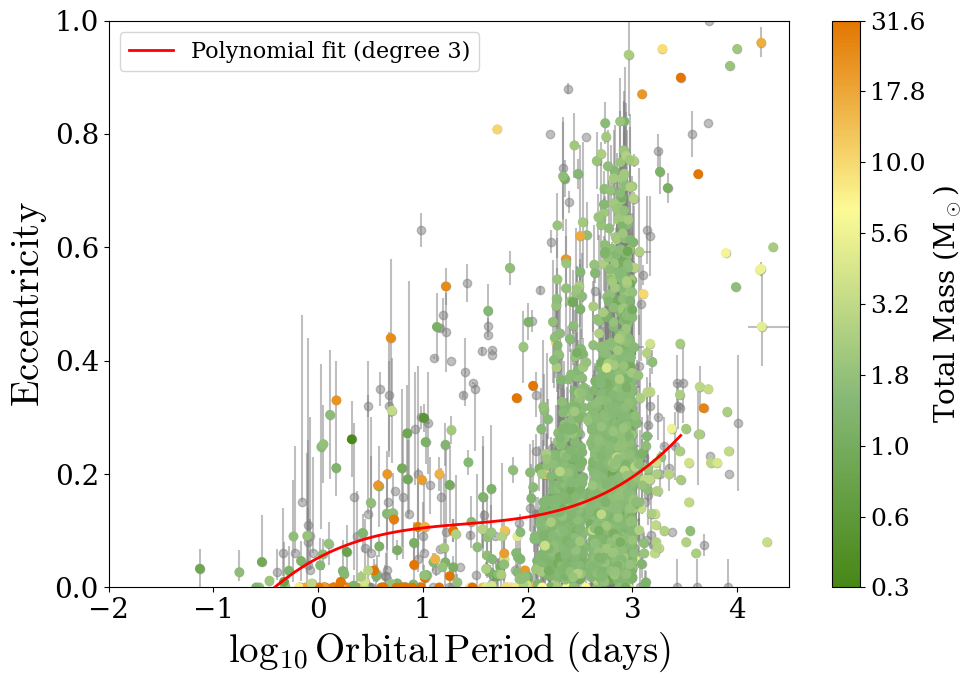

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

plot_df = catalog_df.copy()

plot_df['log_Period'] = np.log10(plot_df['Period'])

###### Handling errors ######
# Propagate errors for logP: d(log P) = 1/ln(10) *  dP /P 
period_err_minus_log = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
period_err_plus_log = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Check that E errors don't drop below zero
# wherever the value minus the minus error is <0, set the minus error to the value itself
mask_min = plot_df['Eccentricity'] - plot_df["Eccentricity_err_minus"] < 0
plot_df.loc[mask_min, "Eccentricity_err_minus"] = plot_df.loc[mask_min, 'Eccentricity'] 
# Also ensure that Eccentricities do not exceed 1
mask_plus = plot_df['Eccentricity'] + plot_df["Eccentricity_err_plus"] > 1
plot_df.loc[mask_plus, "Eccentricity_err_plus"] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Fill NaN errors with zero
period_err_minus_log = period_err_minus_log.fillna(0)
period_err_plus_log = period_err_plus_log.fillna(0)
ecc_err_minus = plot_df['Eccentricity_err_minus'].fillna(0)
ecc_err_plus = plot_df['Eccentricity_err_plus'].fillna(0)


###### Actual plotting ######
## P vs e inlcuding errors ##
ax.errorbar(plot_df['log_Period'], (plot_df['Eccentricity']),
            xerr=[period_err_minus_log, period_err_plus_log], 
            yerr=[ecc_err_minus, ecc_err_plus], zorder = 0,
            fmt='o', c='gray', alpha=0.5)  

## Show Median and 1-sigma ##



## Now overplot colored by total mass ##
plot_df['Mtot'] = plot_df['M1'] + plot_df['M2']
plot_df['log_Mtot'] = np.log10(plot_df['Mtot'])
mass_color_key = 'log_Mtot'

#enforce not na for all three parameters of interest (log_Period, Eccentricity, Mtot)
plot_df = plot_df.dropna(subset=['log_Period', 'Eccentricity', mass_color_key])
mass_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', ['#478716', '#86b976', '#fcfa96','#e37601'])

mass_sc = ax.scatter(plot_df['log_Period'], plot_df['Eccentricity'], 
                    c = plot_df[mass_color_key], cmap=mass_cmap,
                    vmin=-0.5, vmax=1.5)  # Set vmin and vmax for consistent color scaling
cbar = plt.colorbar(mass_sc, ax=ax)


# Set colorbar ticks to show original (non-log) values
tick_locs = cbar.get_ticks() # Get the current tick positions (in log space)
tick_labels = [f'{10**tick:.1f}' for tick in tick_locs] # Convert back from log10 to original values
cbar.set_ticks(tick_locs, labels=tick_labels)

cbar.set_label('Total Mass (M$_\odot$)', fontsize=20)
cbar.ax.tick_params(labelsize=18)


###### Add polynomal fit ######
# Prepare data for fitting (remove NaN values)
fit_df = plot_df.dropna(subset=['log_Period', 'Eccentricity'])

# Limit the fitting range (e.g., only fit data between log_Period = 0 and 3)
x_min, x_max = -1, 3.5
fit_df = fit_df[(fit_df['log_Period'] >= x_min) & (fit_df['log_Period'] <= x_max)]

# Use numpy polyfit (simpler, no errors needed)
degree = 3
coeffs = np.polyfit(fit_df['log_Period'], fit_df['Eccentricity'], deg=degree)

# Create polynomial function
poly_func = np.poly1d(coeffs)

# Generate smooth curve for plotting
x_fit = np.linspace(fit_df['log_Period'].min(), fit_df['log_Period'].max(), 100)
y_fit = poly_func(x_fit)

# Plot the fit
ax.plot(x_fit, y_fit, 'r-', linewidth=2, label=f'Polynomial fit (degree {degree})', zorder=10)

# Print coefficients to see what you got
print(f"Polynomial coefficients: {coeffs}")
print(f"Fit equation: {poly_func}")


###### Plot values ######
plt.xlim(-2,4.5)
plt.ylim(0,1)
# ax.set_xscale('log')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('$\log_{10} \mathrm{Orbital\,Period \ (days)}$', fontsize=28)
plt.ylabel('$\mathrm{Eccentricity}$', fontsize=28)
plt.tight_layout()
ax.legend(fontsize=16)
plt.savefig(PLOTS_DIR / 'P_e_diagram_cmass_general_polyfit.pdf')
plt.show()

# P-e with polynomial fit per mass bin

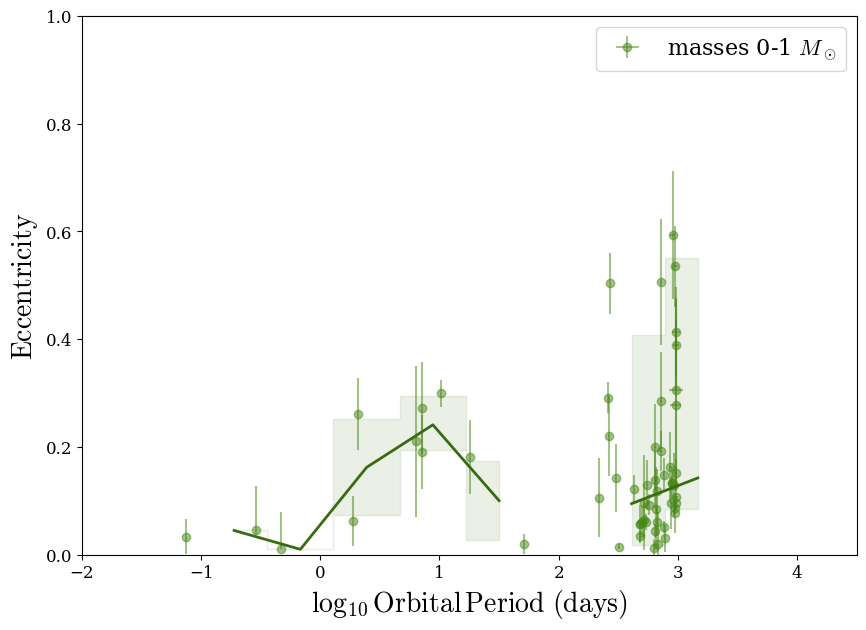

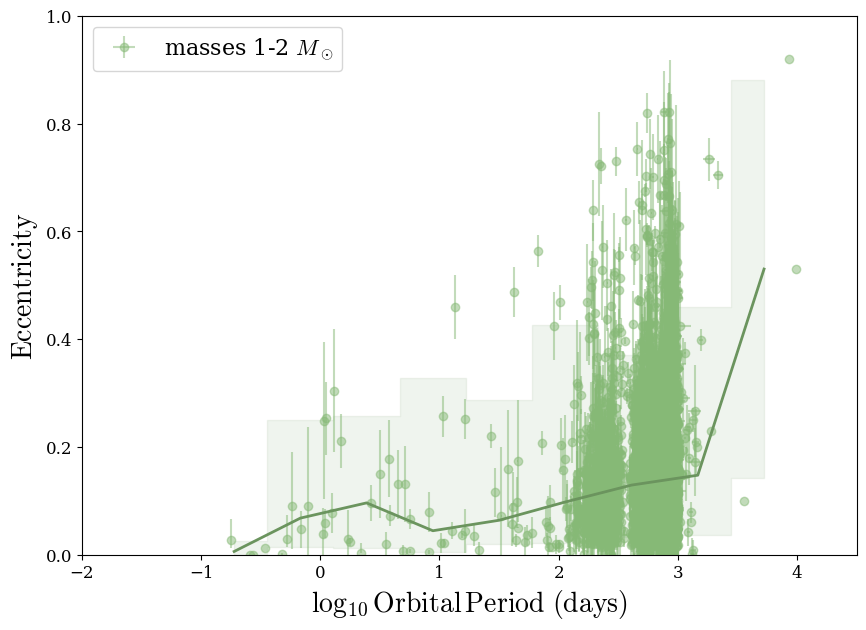

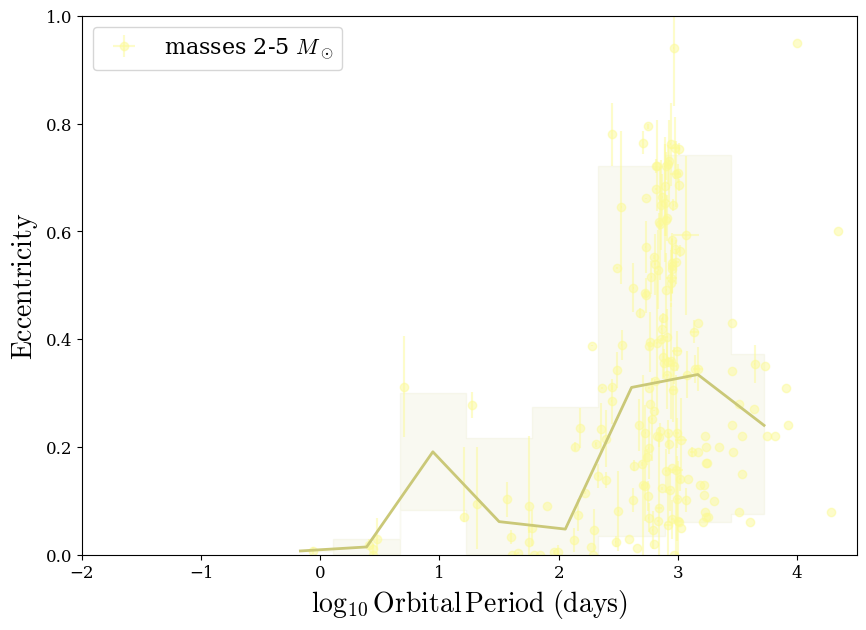

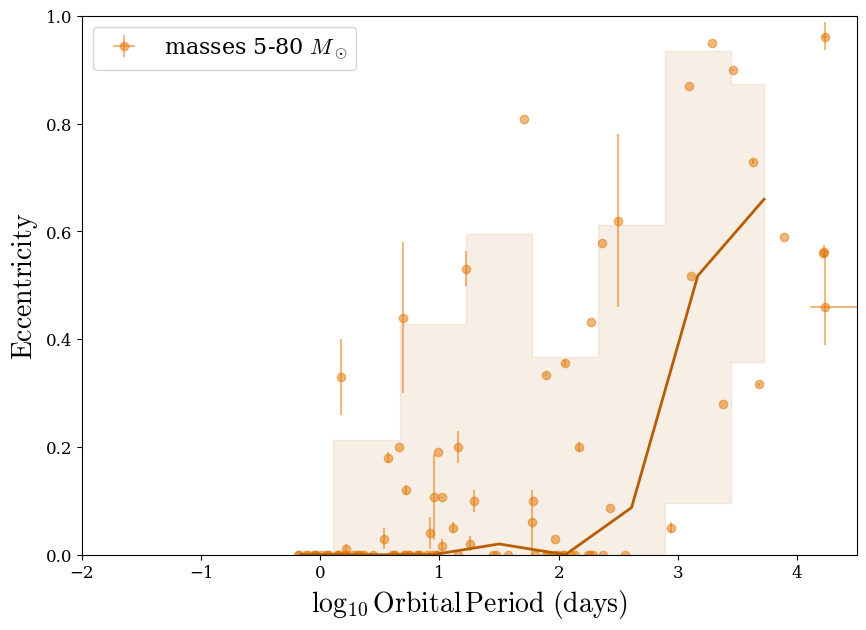

In [15]:
# fig, ax = plt.subplots(figsize=(10, 7))

# Prepare plot_df (this is missing!)
plot_df = catalog_df.copy()
plot_df['log_Period'] = np.log10(plot_df['Period'])
plot_df['Mtot'] = plot_df['M1'] + plot_df['M2']

###### Handling errors ######
# Propagate errors for logP: d(log P) = 1/ln(10) *  dP /P 
plot_df['period_err_minus_log'] = plot_df['Period_err_minus'] / (plot_df['Period'] * np.log(10))
plot_df['period_err_plus_log'] = plot_df['Period_err_plus'] / (plot_df['Period'] * np.log(10))

# Check that E errors don't drop below zero
# wherever the value minus the minus error is <0, set the minus error to the value itself
mask_min = plot_df['Eccentricity'] - plot_df["Eccentricity_err_minus"] < 0
plot_df.loc[mask_min, "Eccentricity_err_minus"] = plot_df.loc[mask_min, 'Eccentricity'] 
# Also ensure that Eccentricities do not exceed 1
mask_plus = plot_df['Eccentricity'] + plot_df["Eccentricity_err_plus"] > 1
plot_df.loc[mask_plus, "Eccentricity_err_plus"] = 1 - plot_df.loc[mask_plus, 'Eccentricity']

# Fill NaN errors with zero
plot_df['period_err_minus_log'] = plot_df['period_err_minus_log'].fillna(0)
plot_df['period_err_plus_log'] = plot_df['period_err_plus_log'].fillna(0)
ecc_err_minus = plot_df['Eccentricity_err_minus'].fillna(0)
ecc_err_plus = plot_df['Eccentricity_err_plus'].fillna(0)


mass_colors = ['#478716', '#86b976', '#fcfa96','#e37601']
mass_bin_edges = [0,1,2,5,80]
###### loop over bins in mass ######
for i in range(len(mass_bin_edges)-1):
    fig, ax = plt.subplots(figsize=(10, 7))

    mass_bin_df = plot_df[(plot_df['Mtot'] >= mass_bin_edges[i]) & (plot_df['Mtot'] < mass_bin_edges[i+1])].copy()

    ###### Actual plotting ######
    ax.errorbar(mass_bin_df['log_Period'], (mass_bin_df['Eccentricity']),
                xerr=[mass_bin_df['period_err_minus_log'], mass_bin_df['period_err_plus_log']], 
                yerr=[mass_bin_df['Eccentricity_err_minus'].fillna(0), mass_bin_df['Eccentricity_err_plus'].fillna(0)], zorder = 0,
                fmt='o', c=mass_colors[i], alpha=0.5, label = 'masses ' + str(mass_bin_edges[i]) + '-' + str(mass_bin_edges[i+1]) + ' $M_\\odot$')

    ## Show Median and 1-sigma ##
    P_bins = np.linspace(-1,4, 10)
    mass_bin_df['P_bin'] = pd.cut(mass_bin_df['log_Period'], bins=P_bins)
    stats = mass_bin_df.groupby('P_bin', observed=False)['Eccentricity'].quantile([0.05, 0.5, 0.95]).unstack()
    stats.columns = ['p05', 'median', 'p95']

    x_stats = P_bins[:-1] + 0.5 * np.diff(P_bins)
    # ax.plot(x_stats, stats['p05'].values, lw=2, ls = ':', c = darken_color(mass_colors[i], factor=0.8))
    ax.plot(x_stats, stats['median'].values, lw=2, c = darken_color(mass_colors[i], factor=0.8))
    # ax.plot(x_stats, stats['p95'].values, lw=2, ls = ':', c = darken_color(mass_colors[i], factor=0.8))
    ax.fill_between(x_stats, stats['p05'].values, stats['p95'].values, color=darken_color(mass_colors[i], factor=0.8), alpha=0.1, step='mid', zorder=-1)
    
    # ###### Add polynomal fit ######
    # # Prepare data for fitting (remove NaN values)
    # fit_df = mass_bin_df.dropna(subset=['log_Period', 'Eccentricity'])

    # # Limit the fitting range (e.g., only fit data between log_Period = 0 and 3)
    # x_min, x_max = -1, 3.9
    # fit_df = fit_df[(fit_df['log_Period'] >= x_min) & (fit_df['log_Period'] <= x_max)]

    # # Use numpy polyfit (simpler, no errors needed)
    # degree = 4
    # coeffs = np.polyfit(fit_df['log_Period'], fit_df['Eccentricity'], deg=degree)

    # # Create polynomial function
    # poly_func = np.poly1d(coeffs)

    # # Generate smooth curve for plotting
    # x_fit = np.linspace(fit_df['log_Period'].min(), fit_df['log_Period'].max(), 100)
    # y_fit = poly_func(x_fit)

    # # Plot the fit
    # ax.plot(x_fit, y_fit, ls ='--', color = darken_color(mass_colors[i], factor=0.8) , linewidth=2, label=f'Polynomial fit (degree {degree})', zorder=10)
    # # Print coefficients to see what you got
    # print(f"Polynomial coefficients: {coeffs}")
    # print(f"Fit equation: {poly_func}")


    ###### Plot values ######
    ax.set_ylim(0, 1)  # Eccentricity is bounded [0,1]
    ax.set_xlim(-2, 4.5)

    ax.legend(fontsize=16)
    plt.xlabel('$\log_{10} \mathrm{Orbital\,Period \ (days)}$', fontsize=20)
    plt.ylabel('$\mathrm{Eccentricity}$', fontsize=20)
    plt.savefig(PLOTS_DIR / f'P_e_diagram_cmass_massbin_{mass_bin_edges[i]}_{mass_bin_edges[i+1]}.pdf')
    plt.show()
